KK1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Datasetet innehåller information om filmer såsom språk, popularitet, budget och betyg. Varje rad representerar en film. Datan kommer från icke verifierbara källor men ska enligt datasetbeskrivningen vara "compiled from various reliable sources" för 3 år sedan. Syftet med analysen är att undersöka vilka faktorer som verkar påverka popularitet och betyg och hur filmer skiljer sig mellan språk och genrer.

In [ ]:
df = pd.read_csv("data/movies.csv")

Strukturen på datasetet.

In [125]:
df.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


Datasetet innehåller 4803 rader (filmer) och 24 kolumner.

In [ ]:
df.shape

Info visar att många filmer saknar hemsida i datasetet men att de flesta filmer har övriga kolumner ifyllda.

In [ ]:
df.info()

Describe visar en del intressant information som t.ex medel spellängd & betyg och även att många filmer har få röster.

In [ ]:
df.describe()

isna().sum() visar att kolumnerna vi är intresserade av "budget, popularity, vote_average, vote_count" är kompletta, förutom "runtime" som har 2 NaN som vi vill ha bort.

In [ ]:
df.isna().sum()

dropna() för att ta bort de 2 filmerna utan "runtime" och en len() efteråt för att visa att datasetet blev 2 rader mindre. (4803 -> 4801)

In [ ]:
df = df.dropna(subset=["runtime"])
len(df)

Filmer med färre än 100 röster filtreras bort eftersom deras betyg och popularitet riskerar att bli missvisande. Ett mycket lågt antal röster gör statistiken mindre tillförlitlig.

In [ ]:
df = df[df["vote_count"] >= 100]
len(df)

Vilka språk har högst genomsnittligt betyg?

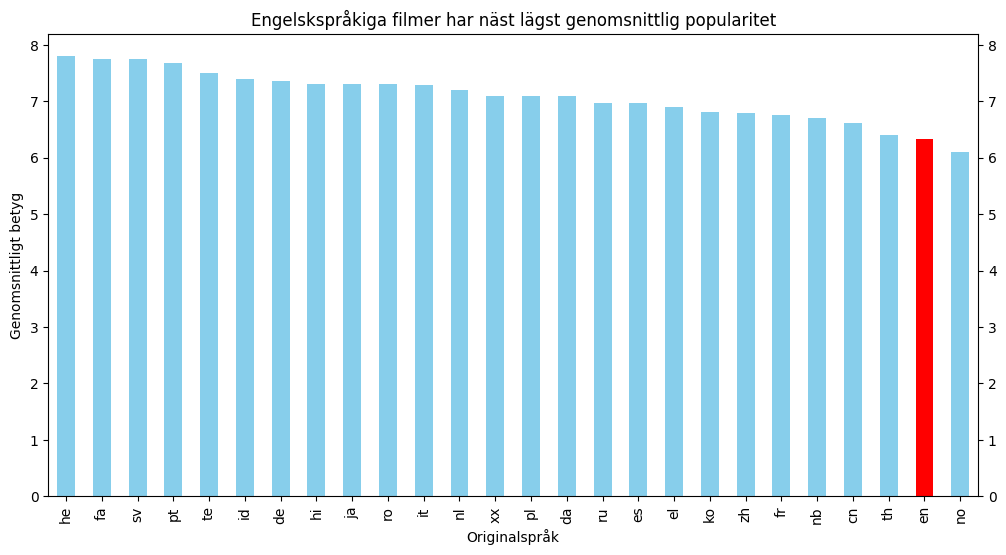

In [115]:
avg_rating = (
    df.groupby("original_language")["vote_average"]
    .mean()
    .sort_values(ascending=False)
)

colors = [
    "red" if lang == "en" else "skyblue"
    for lang in avg_rating.index
]

ax = avg_rating.plot(
    kind="bar",
    figsize=(12, 6),
    color=colors
)

ax.set_title("Engelskspråkiga filmer har näst lägst genomsnittlig popularitet")
ax.set_xlabel("Originalspråk")
ax.set_ylabel("Genomsnittligt betyg")

# Visar även y-axel på höger sida
ax.yaxis.set_ticks_position("both")
ax.tick_params(axis="y", labelright=True)

plt.show()

Finns det samband mellan budget och betyg? 
(Testade hexbin men föredrog scatter som blev tydligare.)

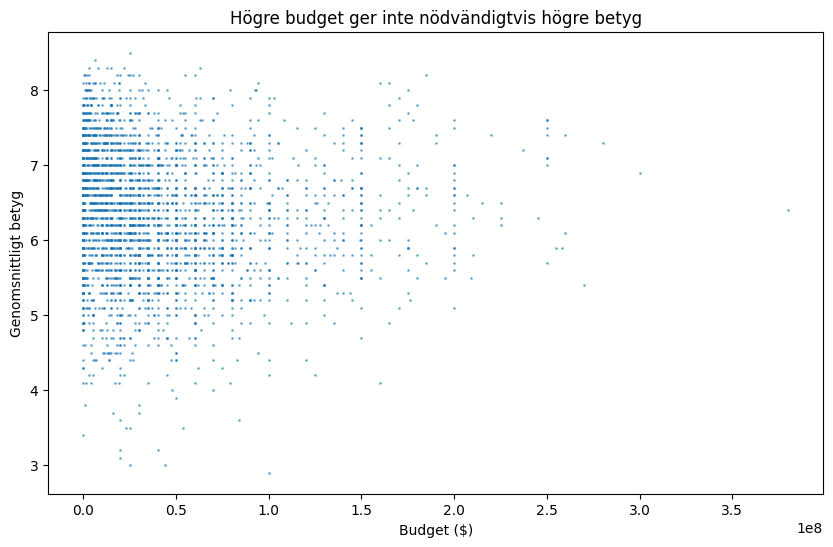

In [128]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df["budget"],
    df["vote_average"],
    alpha=0.5,
    s=1
)

ax.set_title("Högre budget ger inte nödvändigtvis högre betyg")
ax.set_xlabel("Budget ($)")
ax.set_ylabel("Genomsnittligt betyg")

plt.show()

Hur ser fördelningen av betyg ut?

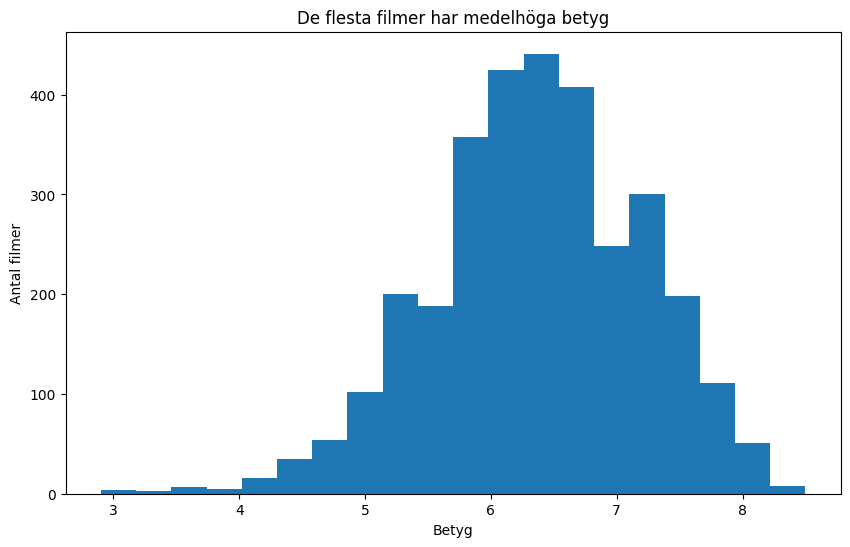

In [117]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(df["vote_average"], bins=20)

ax.set_title("De flesta filmer har medelhöga betyg")
ax.set_xlabel("Betyg")
ax.set_ylabel("Antal filmer")

plt.show()